
# Public ETF data for Dynamic Prediction–Decision Portfolio Learning

<a href="https://colab.research.google.com/github/TiantianZ399/Dynamic-prediction-decision-learning/blob/main/notebooks/01_download_public_etf_data_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

This notebook creates a public, reproducible market-data panel for the repository
[`TiantianZ399/Dynamic-prediction-decision-learning`](https://github.com/TiantianZ399/Dynamic-prediction-decision-learning).

**Default output (the original seven-ETF universe)**

```text
Date,AGG.P,DBC.P,GLD.P,IWM.P,LQD.P,MUB.P,VTI.P
```

It downloads dividend- and split-adjusted daily prices through `yfinance`, aligns the ETFs on the intersection of observed trading dates, computes close-to-close simple returns, performs strict data-quality checks, and writes:

- `data/etfs_aligned_returns_wide.csv` — canonical repository input;
- a dated return snapshot;
- adjusted prices in wide and long formats;
- ticker mapping, quality summary, provenance manifest, SHA-256 hashes, and diagnostic figures;
- a ZIP bundle containing the generated public-data artifacts.

The default dates are fixed through **2024-12-31** to make the paper's 2019–2024 evaluation reproducible. Change the configuration cell deliberately for later samples. Yahoo data accessed through `yfinance` are intended for research/educational use; review the provider's terms before redistribution or commercial use.


## 1. Install the public-data client

In [1]:

import subprocess
import sys

# Pinned to the current release used to construct this notebook.
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "yfinance==1.5.1",
])
print("Installed yfinance 1.5.1")


Installed yfinance 1.5.1


## 2. Imports and reproducibility settings

In [2]:

from __future__ import annotations

import hashlib
import json
import os
import platform
import shutil
import subprocess
import sys
import time
import warnings
import zipfile
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
np.set_printoptions(precision=6, suppress=True)
warnings.filterwarnings("default")

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "yfinance": yf.__version__,
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'yfinance': '1.5.1'}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Clone or reuse the research repository

In [3]:

REPO_URL = "https://github.com/TiantianZ399/Dynamic-prediction-decision-learning.git"
REPO_BRANCH = "codex/public-yahoo-replication"
REPO_DIR = Path("/content/Dynamic-prediction-decision-learning")
CLONE_REPOSITORY = True


def clone_or_reuse_repository(url: str, branch: str, destination: Path) -> Path:
    destination = destination.expanduser().resolve()
    if (destination / ".git").exists():
        print(f"Reusing existing checkout: {destination}")
        return destination
    if destination.exists() and any(destination.iterdir()):
        raise RuntimeError(
            f"{destination} exists but is not a Git checkout. "
            "Choose a different REPO_DIR or remove the directory."
        )
    destination.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "--branch",
            branch,
            url,
            str(destination),
        ],
        check=True,
    )
    print(f"Cloned repository to: {destination}")
    return destination


if CLONE_REPOSITORY:
    PROJECT_ROOT = clone_or_reuse_repository(REPO_URL, REPO_BRANCH, REPO_DIR)
else:
    PROJECT_ROOT = Path("/content/dynamic_portfolio_public_data").resolve()
    PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Repository cloning disabled; using: {PROJECT_ROOT}")

def repository_commit_sha(root: Path) -> str | None:
    if not (root / ".git").exists():
        return None
    try:
        return subprocess.check_output(
            ["git", "-C", str(root), "rev-parse", "HEAD"], text=True
        ).strip()
    except subprocess.CalledProcessError:
        return None

REPOSITORY_COMMIT_SHA = repository_commit_sha(PROJECT_ROOT)
print(f"Repository commit: {REPOSITORY_COMMIT_SHA or 'not a Git checkout'}")

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = DATA_DIR / "public_data_figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


Cloned repository to: /content/Dynamic-prediction-decision-learning
Repository commit: 48b2542da4446a813a17aa9972f331d08d185653


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



## 4. Configuration

The `original_7` mapping preserves the repository's Reuters-style column labels while downloading the corresponding U.S. ETF symbols. The optional `expanded_24` panel supports the reviewer's requested larger-universe robustness analysis.

`END_DATE` is interpreted as **inclusive** by this notebook. The downloader adds one calendar day because `yfinance.download(..., end=...)` treats `end` as exclusive.


In [4]:

UNIVERSES: dict[str, OrderedDict[str, str]] = {
    "original_7": OrderedDict([
        ("AGG.P", "AGG"),   # U.S. aggregate bonds
        ("DBC.P", "DBC"),   # broad commodities
        ("GLD.P", "GLD"),   # gold
        ("IWM.P", "IWM"),   # U.S. small-cap equities
        ("LQD.P", "LQD"),   # investment-grade corporate bonds
        ("MUB.P", "MUB"),   # municipal bonds
        ("VTI.P", "VTI"),   # total U.S. equity market
    ]),
    "expanded_24": OrderedDict([
        ("AGG.P", "AGG"),
        ("DBC.P", "DBC"),
        ("GLD.P", "GLD"),
        ("IWM.P", "IWM"),
        ("LQD.P", "LQD"),
        ("MUB.P", "MUB"),
        ("VTI.P", "VTI"),
        ("QQQ.P", "QQQ"),
        ("EFA.P", "EFA"),
        ("EEM.P", "EEM"),
        ("VNQ.P", "VNQ"),
        ("IEF.P", "IEF"),
        ("TLT.P", "TLT"),
        ("SHY.P", "SHY"),
        ("TIP.P", "TIP"),
        ("HYG.P", "HYG"),
        ("SLV.P", "SLV"),
        ("USO.P", "USO"),
        ("XLE.P", "XLE"),
        ("XLK.P", "XLK"),
        ("XLV.P", "XLV"),
        ("XLF.P", "XLF"),
        ("XLP.P", "XLP"),
        ("BIL.P", "BIL"),
    ]),
}

# For direct replication of the seven-ETF study, keep this as "original_7".
UNIVERSE_KEY = "original_7"

# Fixed sample for reproducible paper results. These dates are inclusive here.
START_DATE = "2008-01-02"
END_DATE = "2024-12-31"

# Data-quality policy.
MAX_MISSING_FRACTION_BEFORE_ALIGNMENT = 0.02
MIN_COMMON_PRICE_OBSERVATIONS = 1_500
MAX_ABS_DAILY_RETURN_HARD = 0.80
DOWNLOAD_ATTEMPTS = 3
DOWNLOAD_TIMEOUT_SECONDS = 30

# Output behavior.
WRITE_CANONICAL_REPO_FILE = True
DOWNLOAD_ZIP_TO_LOCAL_COMPUTER = False

if UNIVERSE_KEY not in UNIVERSES:
    raise KeyError(f"Unknown UNIVERSE_KEY={UNIVERSE_KEY!r}; choose from {list(UNIVERSES)}")
if pd.Timestamp(START_DATE) >= pd.Timestamp(END_DATE):
    raise ValueError("START_DATE must be earlier than END_DATE")

RIC_TO_YAHOO = UNIVERSES[UNIVERSE_KEY]
YAHOO_TO_RIC = {ticker: ric for ric, ticker in RIC_TO_YAHOO.items()}
YAHOO_TICKERS = list(RIC_TO_YAHOO.values())
RIC_COLUMNS = list(RIC_TO_YAHOO.keys())

configuration = pd.DataFrame({
    "RIC_column": RIC_COLUMNS,
    "Yahoo_ticker": YAHOO_TICKERS,
})
print(f"Universe: {UNIVERSE_KEY} ({len(configuration)} assets)")
display(configuration)


Universe: original_7 (7 assets)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,RIC_column,Yahoo_ticker
0,AGG.P,AGG
1,DBC.P,DBC
2,GLD.P,GLD
3,IWM.P,IWM
4,LQD.P,LQD
5,MUB.P,MUB
6,VTI.P,VTI


## 5. Robust adjusted-price downloader

In [5]:

class PublicDataDownloadError(RuntimeError):
    """Raised when a complete public-price panel cannot be obtained."""


def _inclusive_to_exclusive_end(end_date: str) -> str:
    return (pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")


def _normalize_price_index(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    index = pd.DatetimeIndex(pd.to_datetime(result.index, errors="coerce"))
    valid = ~index.isna()
    result = result.loc[valid].copy()
    index = index[valid]
    if index.tz is not None:
        index = index.tz_convert(None)
    result.index = index.normalize()
    result = result[~result.index.duplicated(keep="last")].sort_index()
    result.index.name = "Date"
    return result


def _column_to_ticker(column: object, requested_tickers: Iterable[str]) -> str:
    requested = {str(ticker).upper() for ticker in requested_tickers}
    parts = column if isinstance(column, tuple) else (column,)
    for part in parts:
        candidate = str(part).upper()
        if candidate in requested:
            return candidate
    return str(parts[-1]).upper()


def extract_adjusted_close(
    raw: pd.DataFrame,
    requested_tickers: Iterable[str],
) -> pd.DataFrame:
    """Extract the adjusted Close matrix across yfinance column layouts."""
    tickers = [str(ticker).upper() for ticker in requested_tickers]
    if raw is None or raw.empty:
        return pd.DataFrame(columns=tickers, dtype=float)

    if isinstance(raw.columns, pd.MultiIndex):
        close = None
        for level in range(raw.columns.nlevels):
            values = {str(value) for value in raw.columns.get_level_values(level)}
            if "Close" in values:
                close = raw.xs("Close", axis=1, level=level, drop_level=True)
                break
        if close is None:
            raise PublicDataDownloadError(
                f"Could not locate a Close field in yfinance columns: {raw.columns}"
            )
        if isinstance(close, pd.Series):
            close = close.to_frame()
        close = close.copy()
        close.columns = [
            _column_to_ticker(column, tickers) for column in close.columns
        ]
    else:
        if "Close" not in raw.columns:
            raise PublicDataDownloadError(
                f"Could not locate a Close field in yfinance columns: {list(raw.columns)}"
            )
        if len(tickers) != 1:
            raise PublicDataDownloadError(
                "A non-MultiIndex batch response is ambiguous for multiple tickers."
            )
        close = raw[["Close"]].rename(columns={"Close": tickers[0]})

    close = _normalize_price_index(close)
    close = close.apply(pd.to_numeric, errors="coerce")
    close = close.loc[:, ~close.columns.duplicated(keep="last")]
    available = [ticker for ticker in tickers if ticker in close.columns]
    return close.reindex(columns=available)


def _download_batch_once(
    tickers: list[str],
    start_date: str,
    end_date_inclusive: str,
) -> pd.DataFrame:
    raw = yf.download(
        tickers=tickers,
        start=start_date,
        end=_inclusive_to_exclusive_end(end_date_inclusive),
        interval="1d",
        group_by="column",
        auto_adjust=True,
        repair=True,
        actions=False,
        threads=True,
        progress=False,
        timeout=DOWNLOAD_TIMEOUT_SECONDS,
        multi_level_index=True,
    )
    return extract_adjusted_close(raw, tickers)


def _download_single_once(
    ticker: str,
    start_date: str,
    end_date_inclusive: str,
) -> pd.Series:
    # First retry the download endpoint without threading.
    raw = yf.download(
        tickers=ticker,
        start=start_date,
        end=_inclusive_to_exclusive_end(end_date_inclusive),
        interval="1d",
        auto_adjust=True,
        repair=True,
        actions=False,
        threads=False,
        progress=False,
        timeout=DOWNLOAD_TIMEOUT_SECONDS,
        multi_level_index=True,
    )
    close = extract_adjusted_close(raw, [ticker])
    if ticker in close and close[ticker].notna().any():
        return close[ticker].rename(ticker)

    # Final endpoint fallback for transient batch/download issues.
    history = yf.Ticker(ticker).history(
        start=start_date,
        end=_inclusive_to_exclusive_end(end_date_inclusive),
        interval="1d",
        auto_adjust=True,
        repair=True,
        actions=False,
    )
    if history is None or history.empty or "Close" not in history:
        raise PublicDataDownloadError(f"No adjusted Close history returned for {ticker}")
    series = history["Close"].to_frame(ticker)
    series = _normalize_price_index(series)
    return pd.to_numeric(series[ticker], errors="coerce").rename(ticker)


def download_adjusted_close_panel(
    tickers: Iterable[str],
    start_date: str,
    end_date_inclusive: str,
    attempts: int = 3,
) -> pd.DataFrame:
    ordered_tickers = list(dict.fromkeys(str(t).upper() for t in tickers))
    last_error: Exception | None = None
    batch = pd.DataFrame()

    for attempt in range(1, attempts + 1):
        try:
            print(f"Batch download attempt {attempt}/{attempts} ...")
            candidate = _download_batch_once(
                ordered_tickers,
                start_date,
                end_date_inclusive,
            )
            batch = candidate if batch.empty else batch.combine_first(candidate)
            missing = [
                ticker
                for ticker in ordered_tickers
                if ticker not in batch or not batch[ticker].notna().any()
            ]
            if not missing:
                break
            print(f"Batch response is missing: {missing}")
        except Exception as exc:  # network/API failures vary by release
            last_error = exc
            print(f"Batch attempt failed: {type(exc).__name__}: {exc}")
        if attempt < attempts:
            time.sleep(min(2 ** attempt, 8))

    series_by_ticker: dict[str, pd.Series] = {}
    for ticker in ordered_tickers:
        if ticker in batch and batch[ticker].notna().any():
            series_by_ticker[ticker] = batch[ticker]
            continue

        single_error: Exception | None = None
        for attempt in range(1, attempts + 1):
            try:
                print(f"Individual download {ticker}: attempt {attempt}/{attempts}")
                series_by_ticker[ticker] = _download_single_once(
                    ticker,
                    start_date,
                    end_date_inclusive,
                )
                break
            except Exception as exc:
                single_error = exc
                print(f"  {type(exc).__name__}: {exc}")
                if attempt < attempts:
                    time.sleep(min(2 ** attempt, 8))
        if ticker not in series_by_ticker:
            detail = single_error or last_error or "unknown download error"
            raise PublicDataDownloadError(
                f"Unable to retrieve {ticker} after {attempts} attempts: {detail}"
            )

    panel = pd.concat(series_by_ticker.values(), axis=1)
    panel.columns = list(series_by_ticker)
    panel = _normalize_price_index(panel).reindex(columns=ordered_tickers)

    empty = [ticker for ticker in ordered_tickers if not panel[ticker].notna().any()]
    if empty:
        raise PublicDataDownloadError(f"Empty price histories: {empty}")
    return panel


## 6. Download public adjusted prices

In [6]:

download_started_utc = datetime.now(timezone.utc)
prices_yahoo_raw = download_adjusted_close_panel(
    YAHOO_TICKERS,
    START_DATE,
    END_DATE,
    attempts=DOWNLOAD_ATTEMPTS,
)
download_finished_utc = datetime.now(timezone.utc)

print(
    f"Raw panel: {prices_yahoo_raw.shape[0]:,} dates x "
    f"{prices_yahoo_raw.shape[1]} assets"
)
display(prices_yahoo_raw.head())
display(prices_yahoo_raw.tail())


Batch download attempt 1/3 ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Raw panel: 4,279 dates x 7 assets


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,AGG,DBC,GLD,IWM,LQD,MUB,VTI
Date,,,,,,,
2008-01-02,59.180103,26.991882,84.860001,58.524559,52.906506,62.245528,51.406086
2008-01-03,59.337332,27.199957,85.570000,57.878265,52.731914,62.172452,51.345181
2008-01-04,59.459557,27.041821,85.129997,56.134029,53.165866,62.142046,49.972481
2008-01-07,59.535238,26.550756,84.769997,56.258640,53.100945,62.075069,49.997574
2008-01-08,59.686628,26.792126,86.779999,54.522209,53.001249,61.983778,49.101551


,AGG,DBC,GLD,IWM,LQD,MUB,VTI
Date,,,,,,,
2024-12-24,91.228958,20.354935,241.440002,219.990326,100.010338,101.196777,291.780853
2024-12-26,91.294945,20.296886,243.070007,222.245468,100.103798,101.196777,291.947815
2024-12-27,91.106415,20.393631,241.399994,219.005524,99.683205,101.206291,288.785675
2024-12-30,91.464645,20.577446,240.630005,217.321548,100.113159,101.606720,285.594055
2024-12-31,91.351517,20.683863,242.130005,217.597321,99.860771,101.578094,284.602203


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



## 7. Align and validate the panel

The notebook does **not** forward-fill prices and does **not** replace missing returns with zero. It:

1. restricts the panel to the common availability interval;
2. reports missingness before alignment;
3. drops any date on which at least one requested ETF lacks an adjusted price;
4. computes returns only after that alignment.

This is deliberately conservative for a same-calendar U.S. ETF universe and prevents artificial zero returns from entering training or evaluation.


In [7]:

def align_and_validate_prices(
    raw_prices: pd.DataFrame,
    ticker_order: list[str],
    max_missing_fraction: float,
    min_common_observations: int,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, object]]:
    prices = raw_prices.reindex(columns=ticker_order).copy()
    prices = prices.replace([np.inf, -np.inf], np.nan)

    first_valid = prices.apply(lambda column: column.first_valid_index())
    last_valid = prices.apply(lambda column: column.last_valid_index())
    if first_valid.isna().any() or last_valid.isna().any():
        bad = list(first_valid[first_valid.isna()].index)
        raise ValueError(f"No valid observations for: {bad}")

    common_start = max(first_valid)
    common_end = min(last_valid)
    if common_start >= common_end:
        raise ValueError("The requested assets have no overlapping price interval")

    common_window = prices.loc[common_start:common_end].copy()
    missing_count = common_window.isna().sum()
    missing_fraction = common_window.isna().mean()

    quality = pd.DataFrame({
        "Yahoo_ticker": ticker_order,
        "RIC_column": [YAHOO_TO_RIC[ticker] for ticker in ticker_order],
        "first_valid_date": [first_valid[ticker].date().isoformat() for ticker in ticker_order],
        "last_valid_date": [last_valid[ticker].date().isoformat() for ticker in ticker_order],
        "observations_before_alignment": [int(prices[ticker].notna().sum()) for ticker in ticker_order],
        "missing_in_common_window": [int(missing_count[ticker]) for ticker in ticker_order],
        "missing_fraction_in_common_window": [float(missing_fraction[ticker]) for ticker in ticker_order],
        "minimum_adjusted_price": [float(common_window[ticker].min()) for ticker in ticker_order],
        "maximum_adjusted_price": [float(common_window[ticker].max()) for ticker in ticker_order],
    })

    excessive = quality[
        quality["missing_fraction_in_common_window"] > max_missing_fraction
    ]
    if not excessive.empty:
        raise ValueError(
            "Excessive missing adjusted prices before alignment:\n"
            + excessive[[
                "Yahoo_ticker",
                "missing_fraction_in_common_window",
            ]].to_string(index=False)
        )

    if (common_window <= 0).any().any():
        locations = np.argwhere((common_window <= 0).to_numpy())[:10]
        raise ValueError(f"Non-positive adjusted prices detected at indices: {locations.tolist()}")

    aligned = common_window.dropna(axis=0, how="any")
    if len(aligned) < min_common_observations:
        raise ValueError(
            f"Only {len(aligned):,} common observations; "
            f"minimum required is {min_common_observations:,}."
        )
    if not aligned.index.is_monotonic_increasing or aligned.index.has_duplicates:
        raise ValueError("Aligned dates must be unique and strictly increasing")
    if aligned.isna().any().any():
        raise AssertionError("Aligned price matrix unexpectedly contains missing values")

    alignment = {
        "common_start": aligned.index.min().date().isoformat(),
        "common_end": aligned.index.max().date().isoformat(),
        "rows_in_common_window_before_drop": int(len(common_window)),
        "rows_after_intersection_alignment": int(len(aligned)),
        "rows_dropped_for_partial_missingness": int(len(common_window) - len(aligned)),
    }
    return aligned, quality, alignment


prices_yahoo, quality_summary, alignment_summary = align_and_validate_prices(
    prices_yahoo_raw,
    YAHOO_TICKERS,
    MAX_MISSING_FRACTION_BEFORE_ALIGNMENT,
    MIN_COMMON_PRICE_OBSERVATIONS,
)

print(json.dumps(alignment_summary, indent=2))
display(quality_summary)


{
  "common_start": "2008-01-02",
  "common_end": "2024-12-31",
  "rows_in_common_window_before_drop": 4279,
  "rows_after_intersection_alignment": 4279,
  "rows_dropped_for_partial_missingness": 0
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Yahoo_ticker,RIC_column,first_valid_date,last_valid_date,observations_before_alignment,missing_in_common_window,missing_fraction_in_common_window,minimum_adjusted_price,maximum_adjusted_price
0,AGG,AGG.P,2008-01-02,2024-12-31,4279,0,0.0,53.278590,101.155067
1,DBC,DBC.P,2008-01-02,2024-12-31,4279,0,0.0,9.136448,38.652573
2,GLD,GLD.P,2008-01-02,2024-12-31,4279,0,0.0,70.000000,257.500000
3,IWM,IWM.P,2008-01-02,2024-12-31,4279,0,0.0,27.184673,238.004364
4,LQD,LQD.P,2008-01-02,2024-12-31,4279,0,0.0,42.297591,113.799927
5,MUB,MUB.P,2008-01-02,2024-12-31,4279,0,0.0,55.389346,103.984467
6,VTI,VTI.P,2008-01-02,2024-12-31,4279,0,0.0,24.692358,296.062103


## 8. Compute simple returns and run return-level checks

In [8]:

prices_ric = prices_yahoo.rename(columns=YAHOO_TO_RIC).reindex(columns=RIC_COLUMNS)
returns_ric = prices_ric.pct_change(fill_method=None).iloc[1:].copy()
returns_ric = returns_ric.replace([np.inf, -np.inf], np.nan)

if returns_ric.isna().any().any():
    raise ValueError("Missing or non-finite returns remain after price alignment")
if (returns_ric <= -1.0).any().any():
    raise ValueError("A simple return less than or equal to -100% was detected")
if not returns_ric.index.is_monotonic_increasing or returns_ric.index.has_duplicates:
    raise ValueError("Return dates must be unique and strictly increasing")

maximum_absolute_return = float(returns_ric.abs().to_numpy().max())
if maximum_absolute_return > MAX_ABS_DAILY_RETURN_HARD:
    stacked = returns_ric.abs().stack().sort_values(ascending=False).head(10)
    raise ValueError(
        f"Maximum absolute daily return {maximum_absolute_return:.2%} exceeds "
        f"the hard threshold {MAX_ABS_DAILY_RETURN_HARD:.2%}.\n{stacked}"
    )

annualized_mean = returns_ric.mean() * 252.0
annualized_volatility = returns_ric.std(ddof=1) * np.sqrt(252.0)
asset_statistics = pd.DataFrame({
    "annualized_mean": annualized_mean,
    "annualized_volatility": annualized_volatility,
    "zero_rate_sharpe": annualized_mean / annualized_volatility.replace(0.0, np.nan),
    "minimum_daily_return": returns_ric.min(),
    "maximum_daily_return": returns_ric.max(),
    "maximum_absolute_daily_return": returns_ric.abs().max(),
})
asset_statistics.index.name = "RIC_column"
asset_statistics = asset_statistics.reset_index()

print(
    f"Validated returns: {returns_ric.shape[0]:,} dates x "
    f"{returns_ric.shape[1]} assets; maximum |daily return| = "
    f"{maximum_absolute_return:.2%}"
)
display(returns_ric.head())
display(asset_statistics)


Validated returns: 4,278 dates x 7 assets; maximum |daily return| = 13.27%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


RIC_column,AGG.P,DBC.P,GLD.P,IWM.P,LQD.P,MUB.P,VTI.P
Date,,,,,,,
2008-01-03,0.002657,0.007709,0.008367,-0.011043,-0.003300,-0.001174,-0.001185
2008-01-04,0.002060,-0.005814,-0.005142,-0.030136,0.008229,-0.000489,-0.026735
2008-01-07,0.001273,-0.018159,-0.004229,0.002220,-0.001221,-0.001078,0.000502
2008-01-08,0.002543,0.009091,0.023711,-0.030865,-0.001877,-0.001471,-0.017921
2008-01-09,-0.002341,-0.009941,-0.002650,0.010140,-0.002071,0.002553,0.010584


,RIC_column,annualized_mean,annualized_volatility,zero_rate_sharpe,minimum_daily_return,maximum_daily_return,maximum_absolute_daily_return
0,AGG.P,0.027103,0.055163,0.491319,-0.068395,0.038688,0.068395
1,DBC.P,0.003281,0.194377,0.016882,-0.079444,0.068744,0.079444
2,GLD.P,0.076791,0.173274,0.443180,-0.087808,0.112905,0.112905
3,IWM.P,0.109036,0.251139,0.434165,-0.132669,0.091492,0.132669
4,LQD.P,0.041571,0.091068,0.456483,-0.091110,0.097677,0.097677
5,MUB.P,0.030342,0.054519,0.556544,-0.061506,0.043842,0.061506
6,VTI.P,0.121269,0.201965,0.600444,-0.113808,0.128297,0.128297


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9. Export repository-ready files and a provenance manifest

In [9]:

def dataframe_with_date_column(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    output.index = pd.DatetimeIndex(output.index).strftime("%Y-%m-%d")
    output.index.name = "Date"
    return output.reset_index()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


safe_start = pd.Timestamp(START_DATE).strftime("%Y%m%d")
safe_end = pd.Timestamp(END_DATE).strftime("%Y%m%d")
stem = f"etfs_{UNIVERSE_KEY}_{safe_start}_{safe_end}"

canonical_returns_path = DATA_DIR / "etfs_aligned_returns_wide.csv"
snapshot_returns_path = DATA_DIR / f"{stem}_returns_wide.csv"
prices_wide_path = DATA_DIR / f"{stem}_adjusted_prices_wide.csv"
prices_long_path = DATA_DIR / f"{stem}_adjusted_prices_long.csv"
ticker_map_path = DATA_DIR / f"{stem}_ticker_map.csv"
quality_path = DATA_DIR / f"{stem}_data_quality.csv"
asset_statistics_path = DATA_DIR / f"{stem}_asset_statistics.csv"
manifest_path = DATA_DIR / f"{stem}_manifest.json"
readme_path = DATA_DIR / f"{stem}_README.txt"

returns_output = dataframe_with_date_column(returns_ric)
prices_output = dataframe_with_date_column(prices_ric)
prices_long_output = (
    prices_output
    .melt(id_vars="Date", var_name="RIC", value_name="Price")
    .sort_values(["RIC", "Date"], kind="stable")
    .reset_index(drop=True)
)

snapshot_returns_path.parent.mkdir(parents=True, exist_ok=True)
returns_output.to_csv(snapshot_returns_path, index=False, float_format="%.12g")
if WRITE_CANONICAL_REPO_FILE:
    returns_output.to_csv(canonical_returns_path, index=False, float_format="%.12g")
prices_output.to_csv(prices_wide_path, index=False, float_format="%.12g")
prices_long_output.to_csv(prices_long_path, index=False, float_format="%.12g")
configuration.to_csv(ticker_map_path, index=False)
quality_summary.to_csv(quality_path, index=False)
asset_statistics.to_csv(asset_statistics_path, index=False)

readme_text = f"""Public ETF data bundle for Dynamic Prediction--Decision Portfolio Learning

Universe: {UNIVERSE_KEY}
Requested inclusive dates: {START_DATE} through {END_DATE}
Actual aligned price dates: {alignment_summary['common_start']} through {alignment_summary['common_end']}
Return observations: {len(returns_output)}
Assets: {', '.join(RIC_COLUMNS)}

Source: Yahoo Finance public endpoints accessed through yfinance {yf.__version__}
Price field: adjusted daily Close (auto_adjust=True; repair=True)
Return definition: simple close-to-close return, P_t / P_(t-1) - 1
Alignment: intersection of dates with observed adjusted prices for every asset
Imputation: none

The canonical model input is:
{canonical_returns_path if WRITE_CANONICAL_REPO_FILE else snapshot_returns_path}

This dataset is for academic replication. Review Yahoo's terms before redistribution
or commercial use. Preserve the manifest and hashes with any reported result.
"""
readme_path.write_text(readme_text, encoding="utf-8")

written_files = [
    snapshot_returns_path,
    prices_wide_path,
    prices_long_path,
    ticker_map_path,
    quality_path,
    asset_statistics_path,
    readme_path,
]
if WRITE_CANONICAL_REPO_FILE:
    written_files.insert(0, canonical_returns_path)

manifest = {
    "schema_version": "1.0",
    "generated_at_utc": download_finished_utc.isoformat(),
    "download_started_at_utc": download_started_utc.isoformat(),
    "source": {
        "provider": "Yahoo Finance",
        "client": "yfinance",
        "client_version": yf.__version__,
        "usage_note": "Research/educational use; consult provider terms.",
    },
    "repository": {
        "url": REPO_URL if CLONE_REPOSITORY else None,
        "branch": REPO_BRANCH if CLONE_REPOSITORY else None,
        "commit_sha": REPOSITORY_COMMIT_SHA,
    },
    "query": {
        "requested_start_date_inclusive": START_DATE,
        "requested_end_date_inclusive": END_DATE,
        "request_end_sent_to_yfinance_exclusive": _inclusive_to_exclusive_end(END_DATE),
        "interval": "1d",
        "auto_adjust": True,
        "repair": True,
        "actions": False,
    },
    "universe": {
        "key": UNIVERSE_KEY,
        "asset_count": len(RIC_COLUMNS),
        "ric_to_yahoo": dict(RIC_TO_YAHOO),
    },
    "processing": {
        "price_field": "adjusted Close",
        "return_definition": "simple close-to-close return: P_t / P_(t-1) - 1",
        "alignment": "intersection after restricting to common first/last valid dates",
        "price_imputation": "none",
        "return_imputation": "none",
        "trading_days_per_year_for_descriptive_statistics": 252,
    },
    "alignment": alignment_summary,
    "result": {
        "return_rows": int(len(returns_ric)),
        "price_rows": int(len(prices_ric)),
        "asset_count": int(returns_ric.shape[1]),
        "maximum_absolute_daily_return": maximum_absolute_return,
        "return_start_date": returns_ric.index.min().date().isoformat(),
        "return_end_date": returns_ric.index.max().date().isoformat(),
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "yfinance": yf.__version__,
    },
    "files": {
        path.name: {
            "bytes": int(path.stat().st_size),
            "sha256": sha256_file(path),
        }
        for path in written_files
    },
}
manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding="utf-8")
written_files.append(manifest_path)

print("Wrote:")
for path in written_files:
    print(f"  {path} ({path.stat().st_size:,} bytes)")
print(f"Manifest SHA-256: {sha256_file(manifest_path)}")


Wrote:
  /content/Dynamic-prediction-decision-learning/data/etfs_aligned_returns_wide.csv (561,579 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_returns_wide.csv (561,579 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_adjusted_prices_wide.csv (461,793 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_adjusted_prices_long.csv (923,893 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_ticker_map.csv (94 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_data_quality.csv (723 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_asset_statistics.csv (1,024 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs_original_7_20080102_20241231_README.txt (871 bytes)
  /content/Dynamic-prediction-decision-learning/data/etfs

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 10. Diagnostic figures

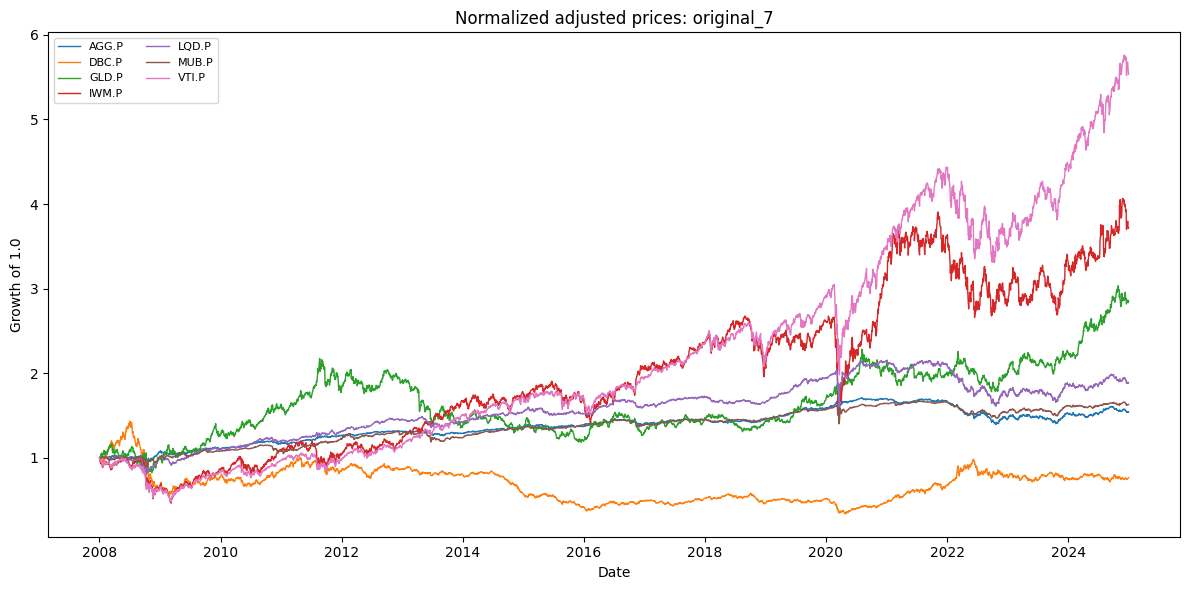

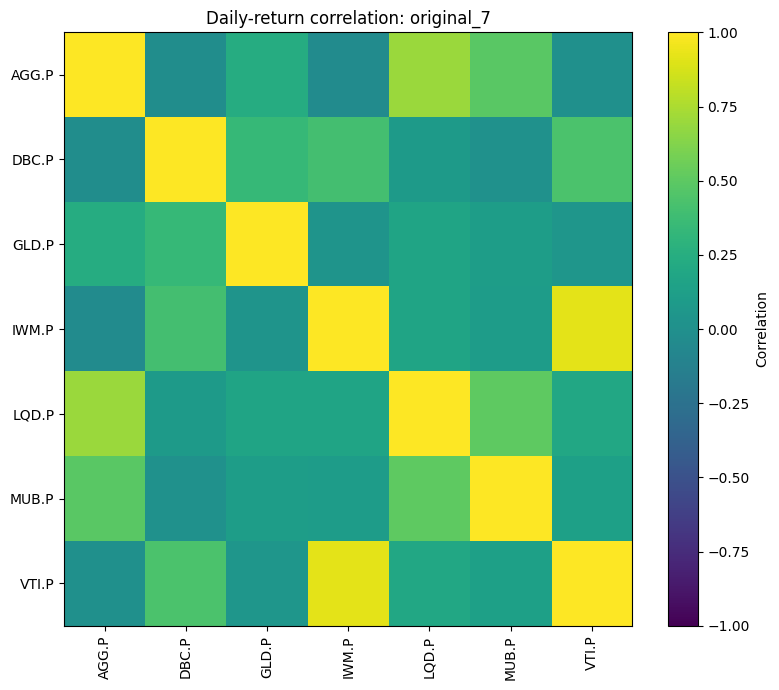

/content/Dynamic-prediction-decision-learning/data/public_data_figures/etfs_original_7_20080102_20241231_normalized_adjusted_prices.png
/content/Dynamic-prediction-decision-learning/data/public_data_figures/etfs_original_7_20080102_20241231_return_correlation.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:

normalized_prices = prices_ric / prices_ric.iloc[0]
figure_path = FIGURE_DIR / f"{stem}_normalized_adjusted_prices.png"

plt.figure(figsize=(12, 6))
for column in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[column], label=column, linewidth=1.0)
plt.title(f"Normalized adjusted prices: {UNIVERSE_KEY}")
plt.xlabel("Date")
plt.ylabel("Growth of 1.0")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

correlation = returns_ric.corr()
correlation_path = FIGURE_DIR / f"{stem}_return_correlation.png"

plt.figure(figsize=(8, 7))
image = plt.imshow(correlation.to_numpy(), vmin=-1, vmax=1, aspect="auto")
plt.colorbar(image, label="Correlation")
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.index)), correlation.index)
plt.title(f"Daily-return correlation: {UNIVERSE_KEY}")
plt.tight_layout()
plt.savefig(correlation_path, dpi=160, bbox_inches="tight")
plt.show()

print(figure_path)
print(correlation_path)


## 11. Verify exact compatibility with the repository loader

In [11]:

loader_path = PROJECT_ROOT / "src" / "dynport" / "data.py"
if loader_path.exists():
    source_path = str(PROJECT_ROOT / "src")
    if source_path not in sys.path:
        sys.path.insert(0, source_path)

    from dynport.data import load_returns

    verification_path = (
        canonical_returns_path
        if WRITE_CANONICAL_REPO_FILE
        else snapshot_returns_path
    )
    loaded_dates, loaded_assets, loaded_returns = load_returns(verification_path)

    if list(loaded_assets) != RIC_COLUMNS:
        raise AssertionError(
            f"Loader asset order mismatch: {loaded_assets} != {RIC_COLUMNS}"
        )
    if loaded_returns.shape != returns_ric.shape:
        raise AssertionError(
            f"Loader shape mismatch: {loaded_returns.shape} != {returns_ric.shape}"
        )
    np.testing.assert_allclose(
        loaded_returns,
        returns_ric.to_numpy(dtype=float),
        rtol=1e-9,
        atol=1e-11,
    )
    print(
        "Repository loader verification passed:",
        loaded_returns.shape,
        pd.Timestamp(loaded_dates[0]).date(),
        "through",
        pd.Timestamp(loaded_dates[-1]).date(),
    )
else:
    print(
        "Repository loader was not found; CSV schema checks still passed. "
        f"Expected loader path: {loader_path}"
    )


Repository loader verification passed: (4278, 7) 2008-01-03 through 2024-12-31


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



## 12. Optional experiment commands

The cell below prints commands rather than launching a long training run automatically. Run the 3-roll smoke command first. Only use the full public-data result when `run_full_oos_fair_eval.py` is present in the cloned commit; the notebook prints both commands in that case.


In [12]:

model_input = (
    canonical_returns_path
    if WRITE_CANONICAL_REPO_FILE
    else snapshot_returns_path
)

full_oos_script = PROJECT_ROOT / "scripts" / "run_full_oos_fair_eval.py"
legacy_script = PROJECT_ROOT / "scripts" / "run_deep_cql_fqi.py"

if full_oos_script.exists():
    smoke_command = [
        sys.executable,
        str(full_oos_script),
        "--data_path",
        str(model_input),
        "--out_dir",
        str(PROJECT_ROOT / "outputs" / f"public_{UNIVERSE_KEY}_smoke"),
        "--start_date", "2019-01-02",
        "--end_date", "2024-12-31",
        "--encoder", "cnn_lstm",
        "--train_len", "250",
        "--test_len", "20",
        "--seq_len", "120",
        "--fqi_iters", "1",
        "--epochs_per_iter", "1",
        "--hidden", "16",
        "--eval_cost", "0.002",
        "--reward_cost", "0.002",
        "--risk_coef", "0.25",
        "--switch_thresholds", "0", "0.1", "0.2",
        "--max_rolls", "3",
        "--seed", "2021",
    ]
    full_command = smoke_command.copy()
    full_command[full_command.index("--out_dir") + 1] = str(PROJECT_ROOT / "outputs" / f"full_oos_{UNIVERSE_KEY}")
    full_command[full_command.index("--max_rolls") + 1] = "-1"
    print("3-roll smoke command (interface check only):\n")
    print(" \\\n  ".join(smoke_command))
    print("\nFull 2019-2024 OOS command (report this output, not the smoke test):\n")
    print(" \\\n  ".join(full_command))
elif legacy_script.exists():
    command = [
        sys.executable,
        str(legacy_script),
        "--data_path",
        str(model_input),
        "--out_dir",
        str(PROJECT_ROOT / "outputs" / f"public_{UNIVERSE_KEY}_deep_cql"),
        "--start_date", "2019-01-02",
        "--end_date", "2024-12-31",
        "--train_len", "250",
        "--test_len", "20",
        "--seq_len", "120",
        "--max_rolls", "3",
        "--eval_cost", "0.002",
        "--reward_cost", "0.002",
        "--risk_coef", "0.25",
    ]
    print("Legacy 3-roll smoke command only; this checkout lacks run_full_oos_fair_eval.py. Request the full-OOS commit before reporting public-data results.\n")
    print(" \\\n  ".join(command))
else:
    print("No recognized experiment runner was found in the checkout.")


3-roll smoke command (interface check only):

/usr/bin/python3 \
  /content/Dynamic-prediction-decision-learning/scripts/run_full_oos_fair_eval.py \
  --data_path \
  /content/Dynamic-prediction-decision-learning/data/etfs_aligned_returns_wide.csv \
  --out_dir \
  /content/Dynamic-prediction-decision-learning/outputs/public_original_7_smoke \
  --start_date \
  2019-01-02 \
  --end_date \
  2024-12-31 \
  --encoder \
  cnn_lstm \
  --train_len \
  250 \
  --test_len \
  20 \
  --seq_len \
  120 \
  --fqi_iters \
  1 \
  --epochs_per_iter \
  1 \
  --hidden \
  16 \
  --eval_cost \
  0.002 \
  --reward_cost \
  0.002 \
  --risk_coef \
  0.25 \
  --switch_thresholds \
  0 \
  0.1 \
  0.2 \
  --max_rolls \
  3 \
  --seed \
  2021

Full 2019-2024 OOS command (report this output, not the smoke test):

/usr/bin/python3 \
  /content/Dynamic-prediction-decision-learning/scripts/run_full_oos_fair_eval.py \
  --data_path \
  /content/Dynamic-prediction-decision-learning/data/etfs_aligned_return

## 13. Create and optionally download the public-data bundle

In [13]:

bundle_path = PROJECT_ROOT / f"public_etf_data_{UNIVERSE_KEY}_{safe_start}_{safe_end}.zip"
files_for_bundle = list(written_files) + [figure_path, correlation_path]

with zipfile.ZipFile(bundle_path, mode="w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in files_for_bundle:
        archive.write(path, arcname=path.relative_to(PROJECT_ROOT))

print(f"Bundle: {bundle_path} ({bundle_path.stat().st_size:,} bytes)")
print(f"Bundle SHA-256: {sha256_file(bundle_path)}")

if DOWNLOAD_ZIP_TO_LOCAL_COMPUTER:
    try:
        from google.colab import files
        files.download(str(bundle_path))
    except ImportError:
        print("Not running in Google Colab; download the ZIP from the shown path.")
else:
    print(
        "Set DOWNLOAD_ZIP_TO_LOCAL_COMPUTER = True in the configuration cell "
        "and rerun this cell to trigger a browser download."
    )


Bundle: /content/Dynamic-prediction-decision-learning/public_etf_data_original_7_20080102_20241231.zip (1,188,390 bytes)
Bundle SHA-256: a5f738ba5ef12d0d6eb1f9d86e6370961ea173d15b9b12e5f107cde1053111f0
Set DOWNLOAD_ZIP_TO_LOCAL_COMPUTER = True in the configuration cell and rerun this cell to trigger a browser download.



## Reporting checklist

For each manuscript table or figure generated from this panel, preserve:

1. the dated returns CSV rather than only the canonical alias;
2. the JSON manifest and all SHA-256 hashes;
3. the ticker mapping and exact inclusive sample dates;
4. the `yfinance` version and retrieval timestamp;
5. the alignment rule (“intersection, no imputation”);
6. the transaction-cost convention used downstream.

For a stronger robustness section, rerun the notebook with `UNIVERSE_KEY = "expanded_24"`, write to a separate output directory, and report results separately from the original seven-ETF replication.
